In [199]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))

import lib_plot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [200]:
from lib_equations import bisec
func = lambda x: 1/2 + x - x**2

start, end = (0, 2)
xcoo = np.linspace(start, end, 100)
ycoo = func(xcoo)

C_TRUE = (1 + np.sqrt(3)) / 2
print(f'c true = {C_TRUE}')

c_clas, N_iter = bisec(func, start, end, optim=False, out_niter=True)
print('\nBISECTION MTH')
print('     Found f(c) = 0:  c = ', c_clas)
print('     N_iter = ', N_iter)

print()
c_optim, N_iter = bisec(func, start, end, optim=True, out_niter=True)
print('REGULA FALSI')
print('     Found f(c) = 0:  c = ', c_optim)
print('     N_iter = ', N_iter)


diff = abs(c_clas - c_optim)
print('\ndiff =', diff)



c true = 1.3660254037844386

BISECTION MTH
     Found f(c) = 0:  c =  1.3660254031419754
     N_iter =  27

REGULA FALSI
     Found f(c) = 0:  c =  1.3660253992204199
     N_iter =  16

diff = 3.921555524755149e-09


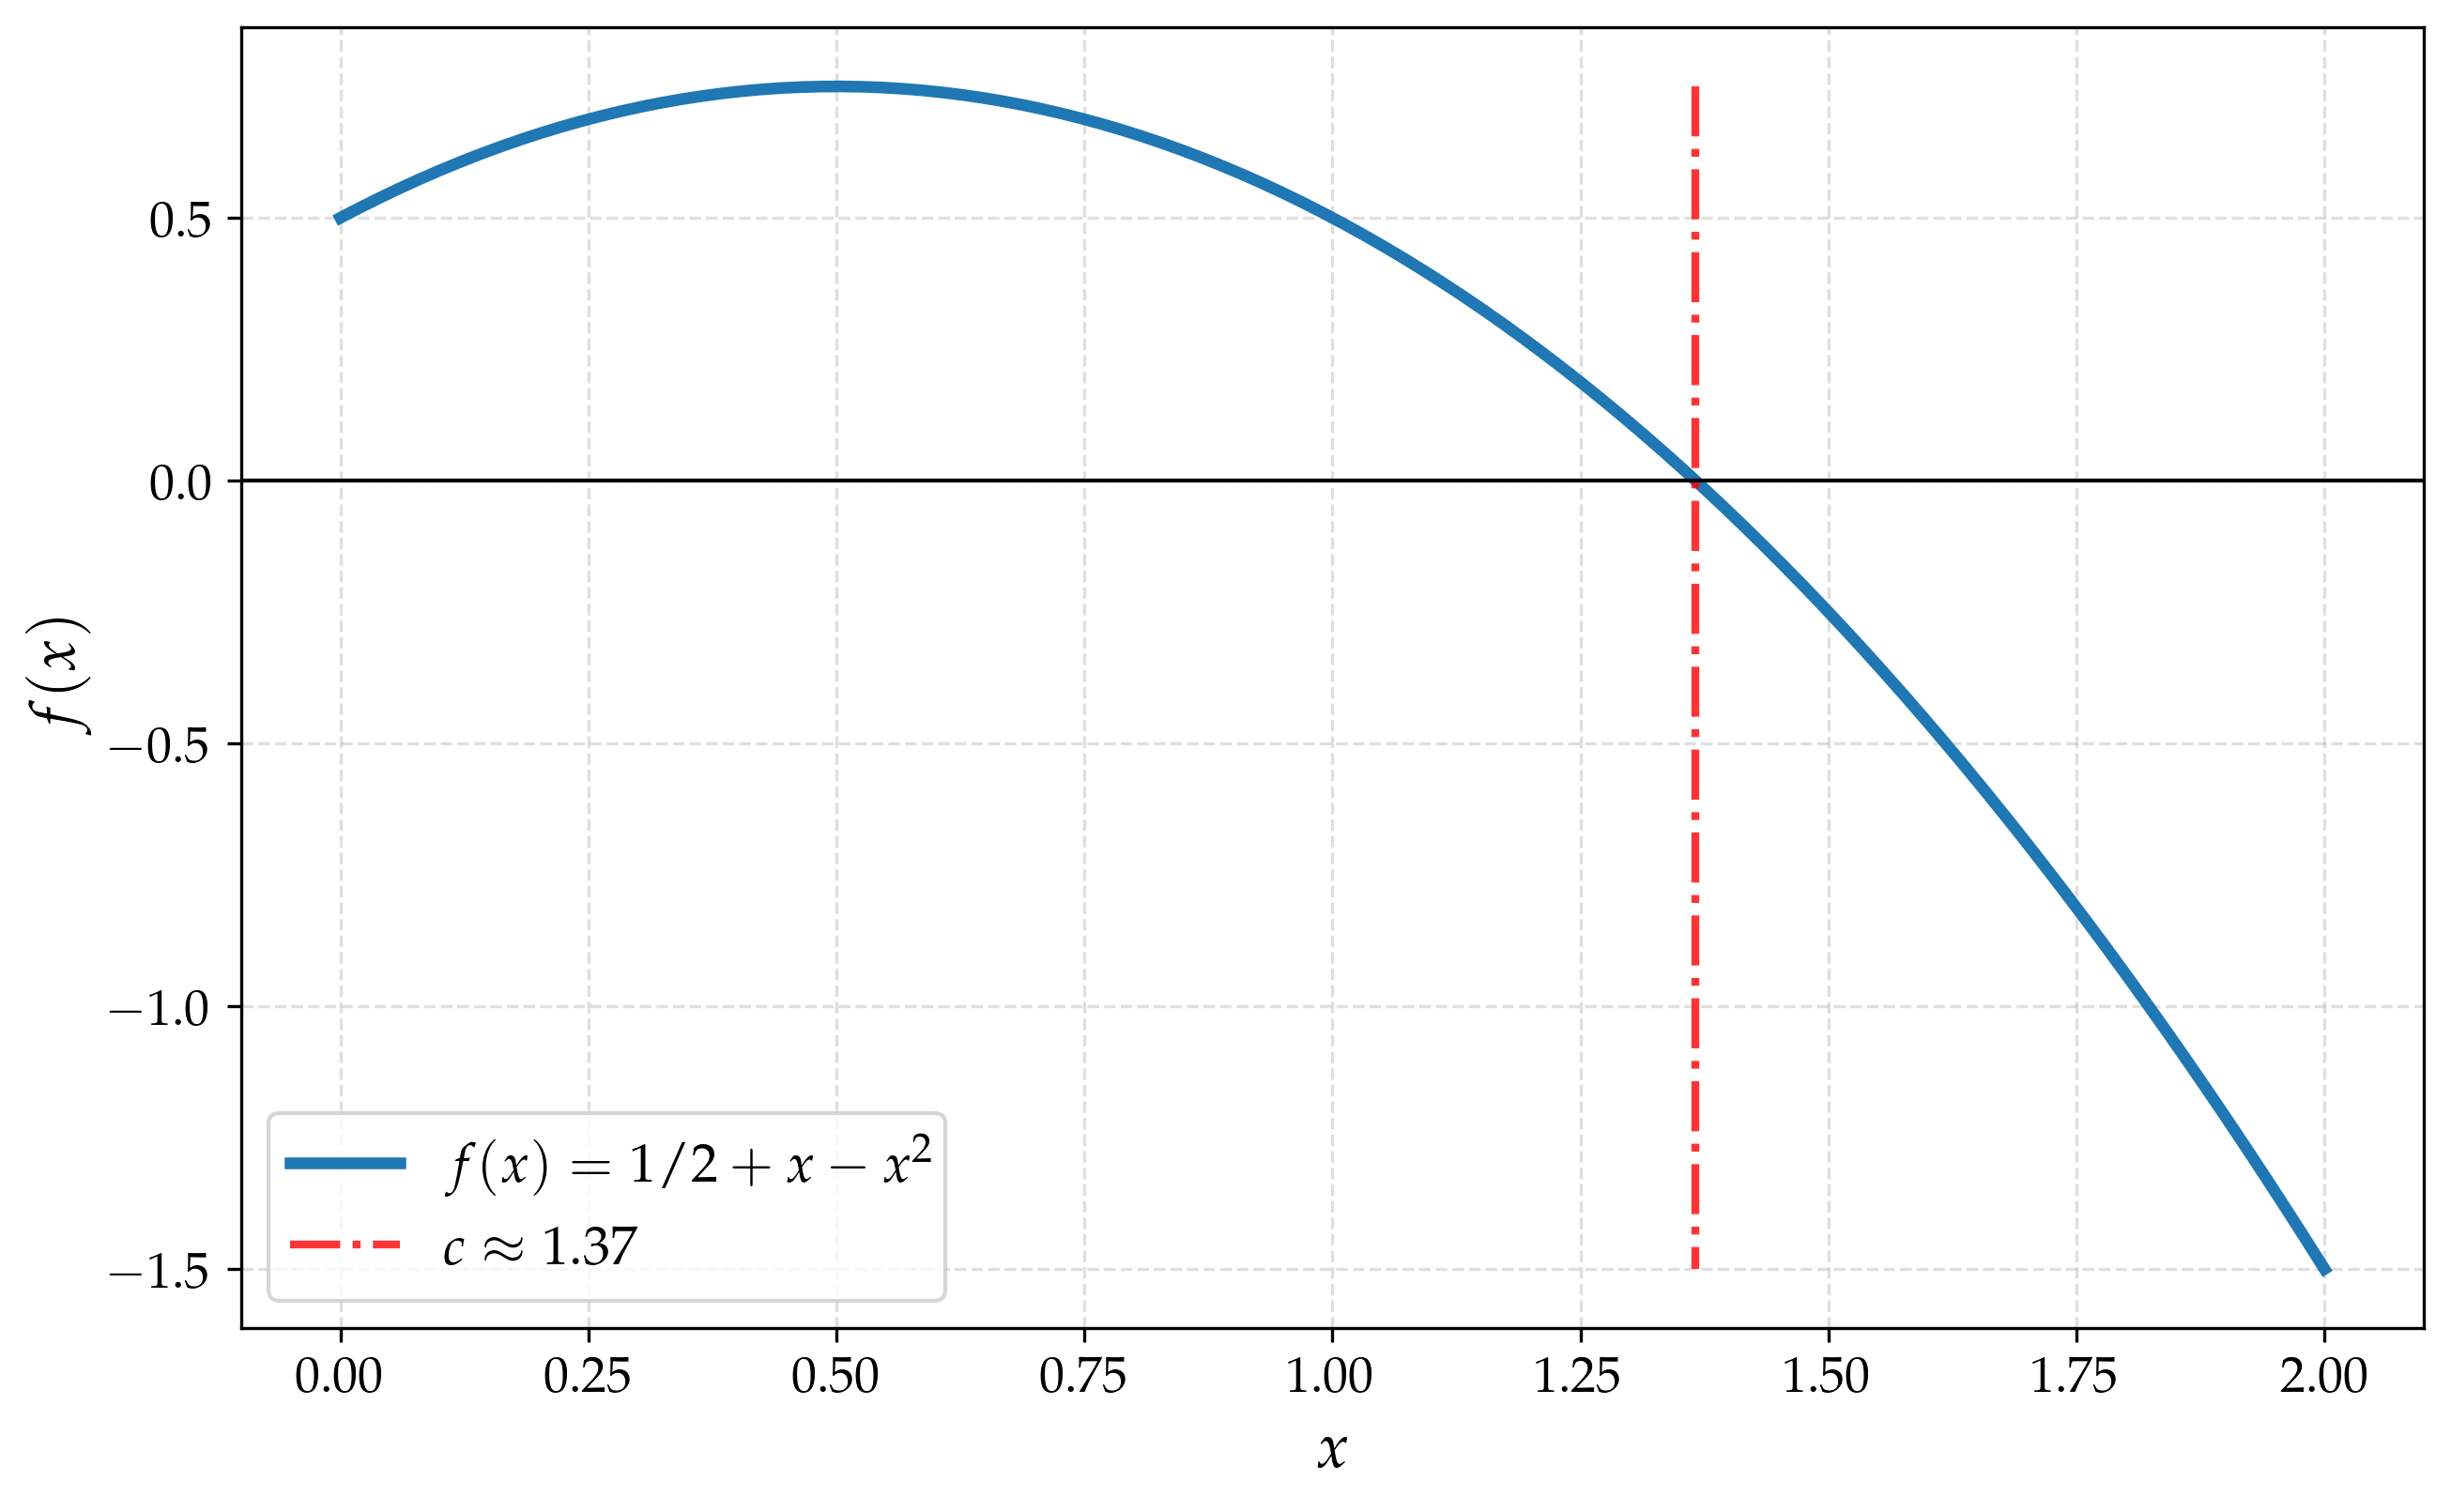

In [201]:

plt.figure(figsize=(10, 6))
plt.plot(xcoo, ycoo, label=r'$f(x) = 1/2 + x - x^2$', lw=3)
plt.vlines(c_optim, max(ycoo), min(ycoo), ls='-.', lw=2, color='red', alpha=0.8, label=rf'$c \approx {c_optim:.2f}$')
# plt.hlines(0, start, end, ls='-', color='black', alpha=1, label=r'$f(x) = 0$')
plt.xlabel(r'$x$')
plt.ylabel(r'$f(x)$')
plt.axhline(0, color='black', linewidth=1)
plt.grid(alpha=0.4, ls='--')
plt.legend(loc='lower left')
plt.savefig('plots/plot_zero.png')
plt.show()


## **Comparison between Classic and Optimized Mths**


BISECTION MTH


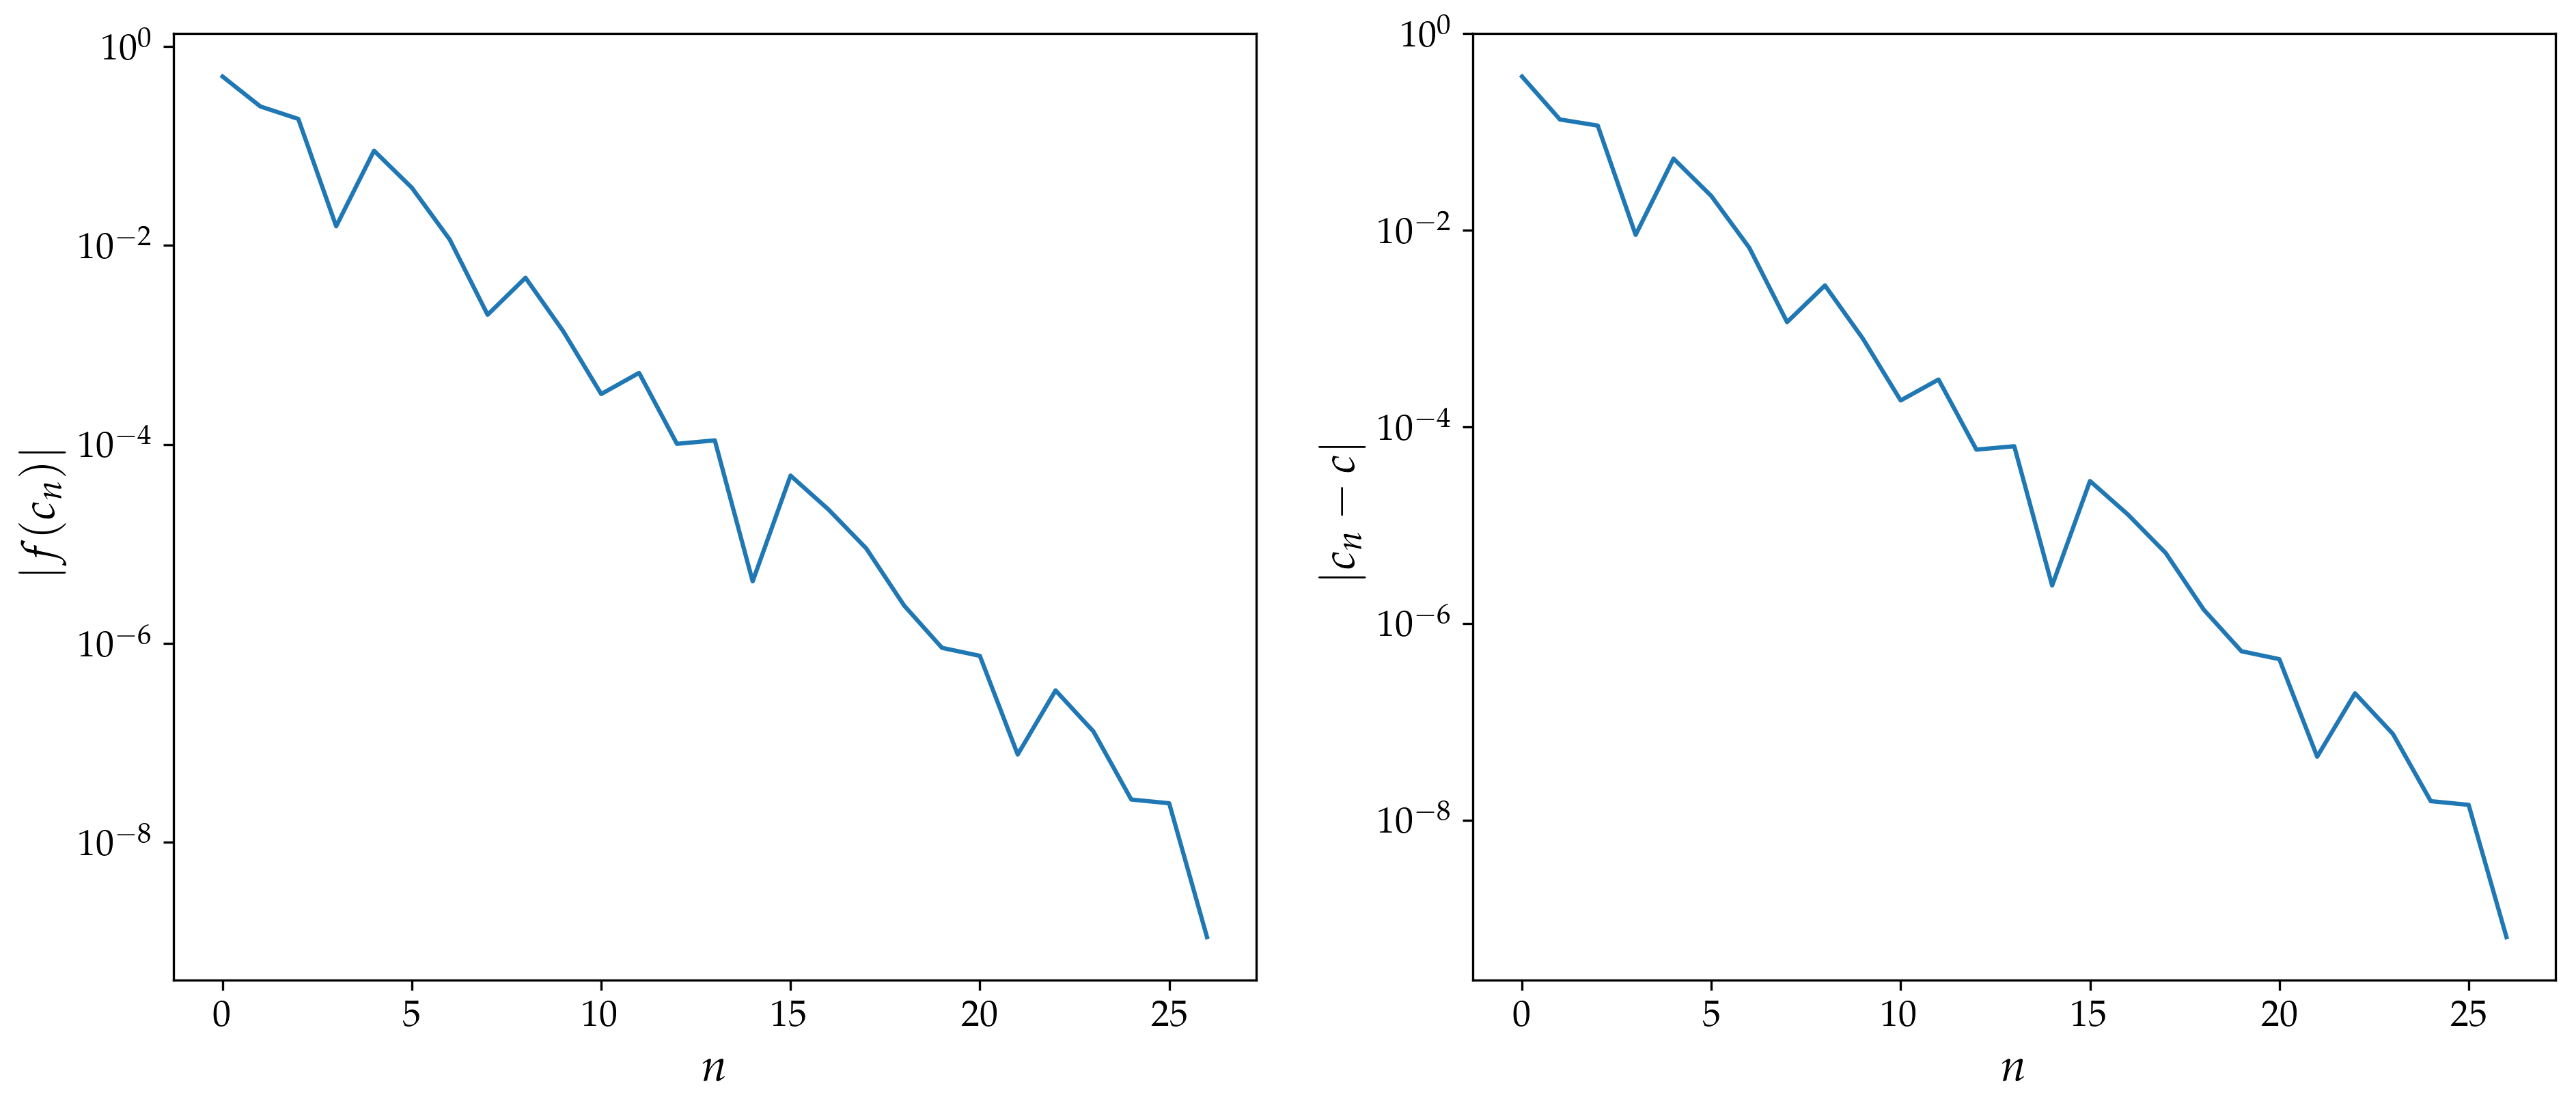

REGULA FALSI


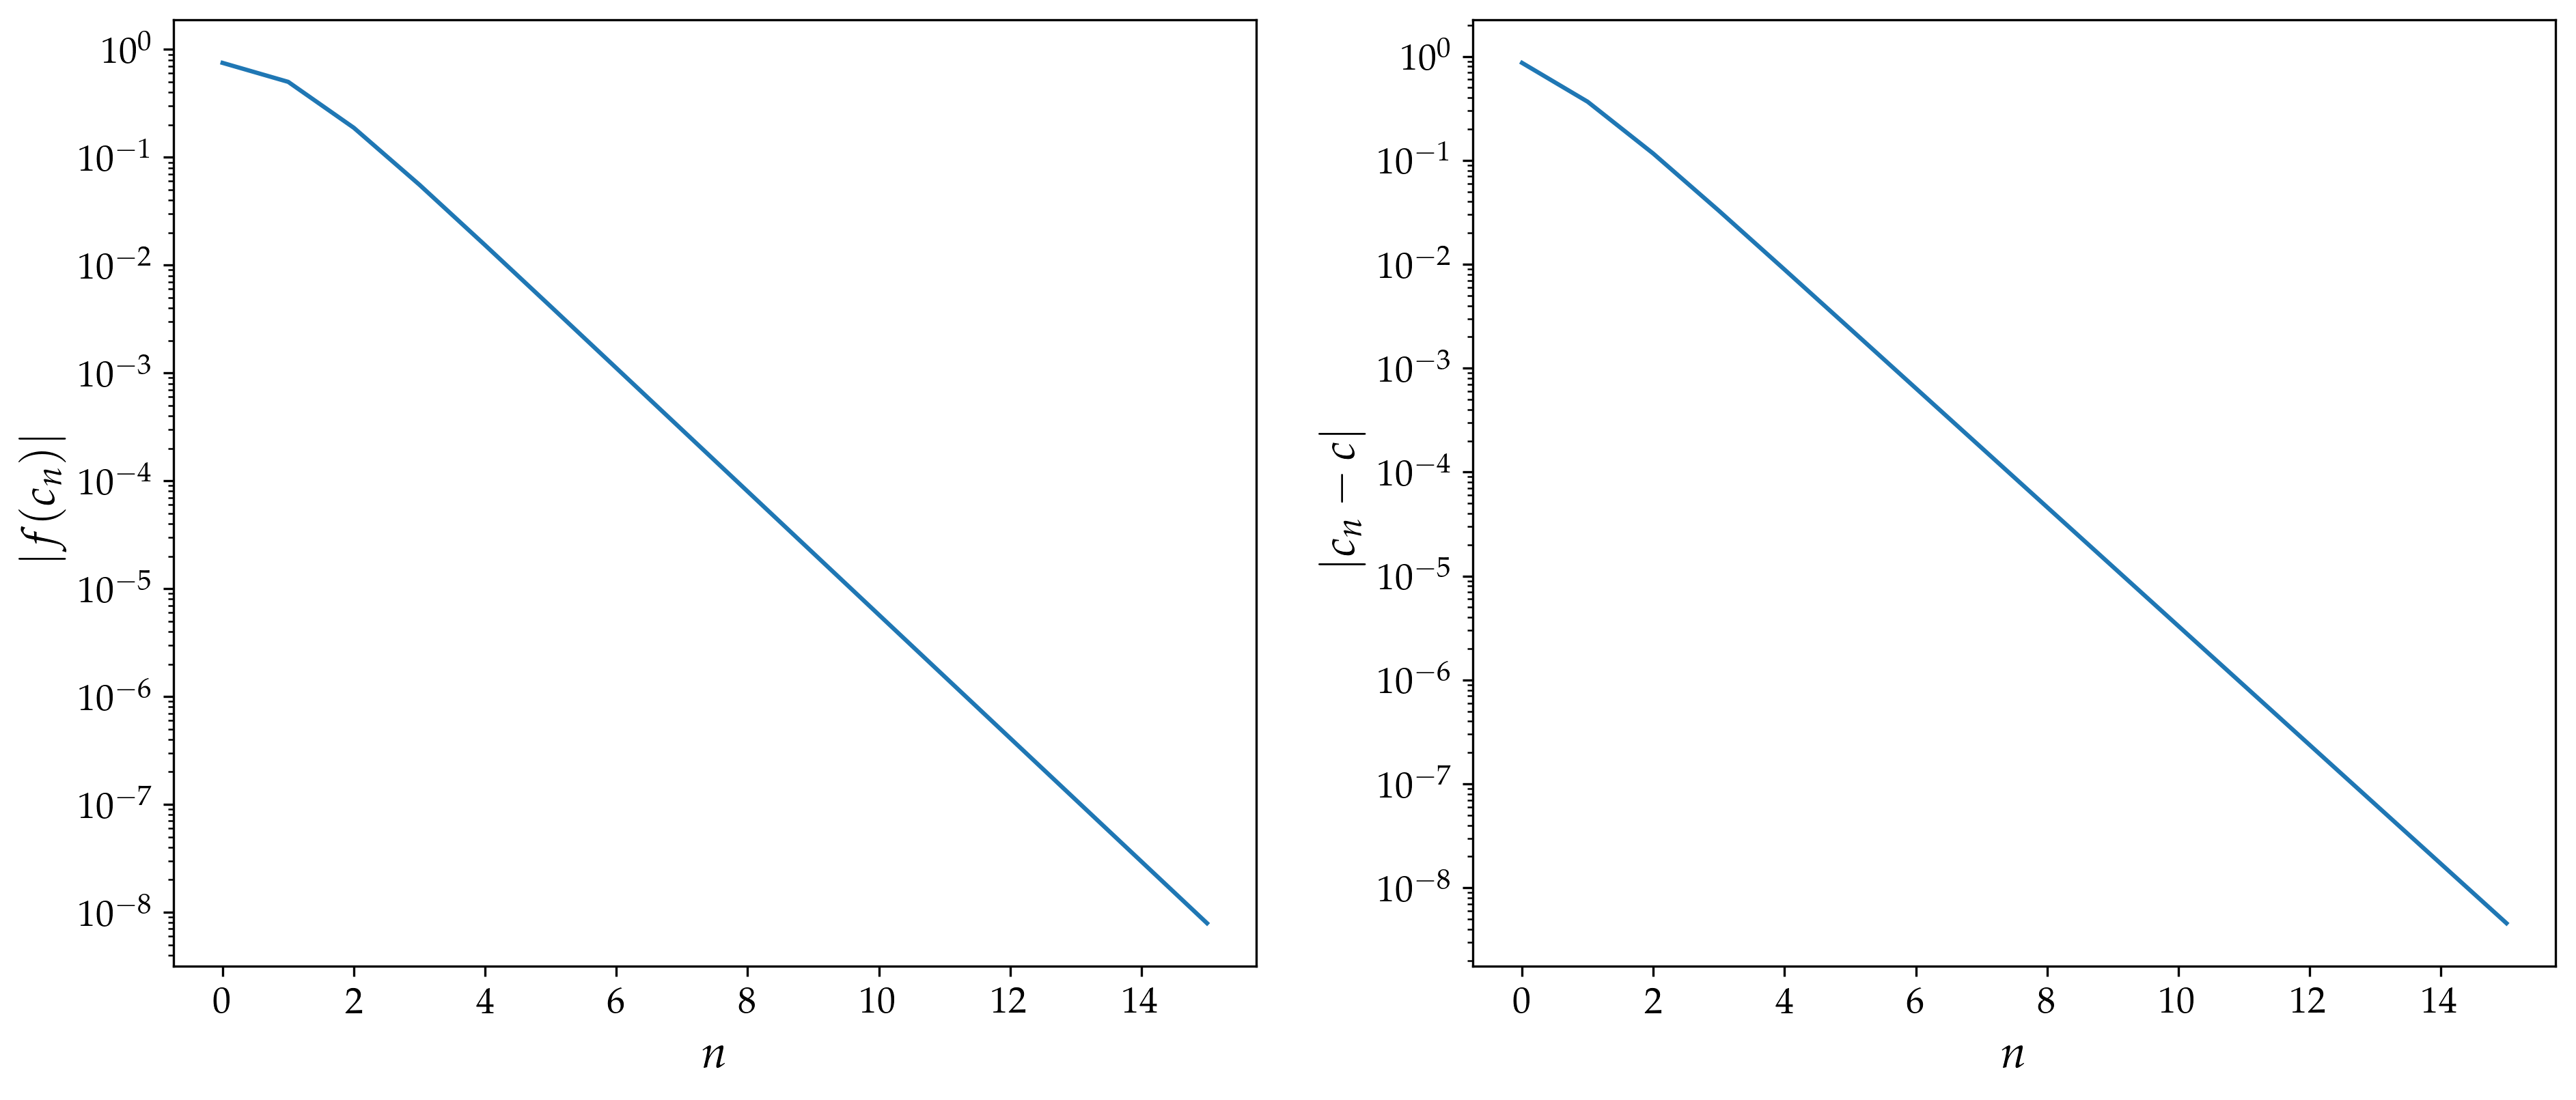

In [202]:
def plot_bisec(f, a, b, optim=True, tol=1e-8, MaxIter=500):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError('f(a) and f(b) must have different sign!')

    n_iter = 0
    f_ls = []
    diff_c = []

    while n_iter < MaxIter:
        if optim:
            den = fb - fa
            if abs(den) < tol: 
                c = (a + b) / 2
            else:
                c = (a * fb - b * fa) / den
        else:
            c = (a + b) / 2

        fc = f(c)

        if fa * fc > 0:
            a, fa = c, fc
        else:
            b, fb = c, fc
        
        diff_c.append(c)
        f_ls.append(fc)
        n_iter += 1
        
        if abs(fc) < tol or abs(b - a) < tol:
            break
            
    return f_ls, diff_c, c, n_iter

def plotty(res, name):
    fls, cls, c, niter = res
    xcoo = np.arange(0, niter)
    f = abs(np.array(fls))
    cs = abs(np.array(cls) - C_TRUE)

    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    ax[0].plot(xcoo, f)
    ax[0].set_xlabel(r'$n$')
    ax[0].set_ylabel(r'$|f(c_n)|$')
    ax[0].set_yscale('log')

    ax[1].plot(xcoo, cs)
    ax[1].set_xlabel(r'$n$')
    ax[1].set_ylabel(r'$|c_n - c|$')
    ax[1].set_yscale('log')
    plt.savefig('plots/'+name+'.png')
    plt.show()

start, end = (0, 2)
print('\nBISECTION MTH')
plotty(plot_bisec(func, start, end, optim=False), 'bis_class')

print('REGULA FALSI')
plotty(plot_bisec(func, start, end, optim=True,), 'optim_bis')

## **Kepler's Problem**

T = 12.566370614359172


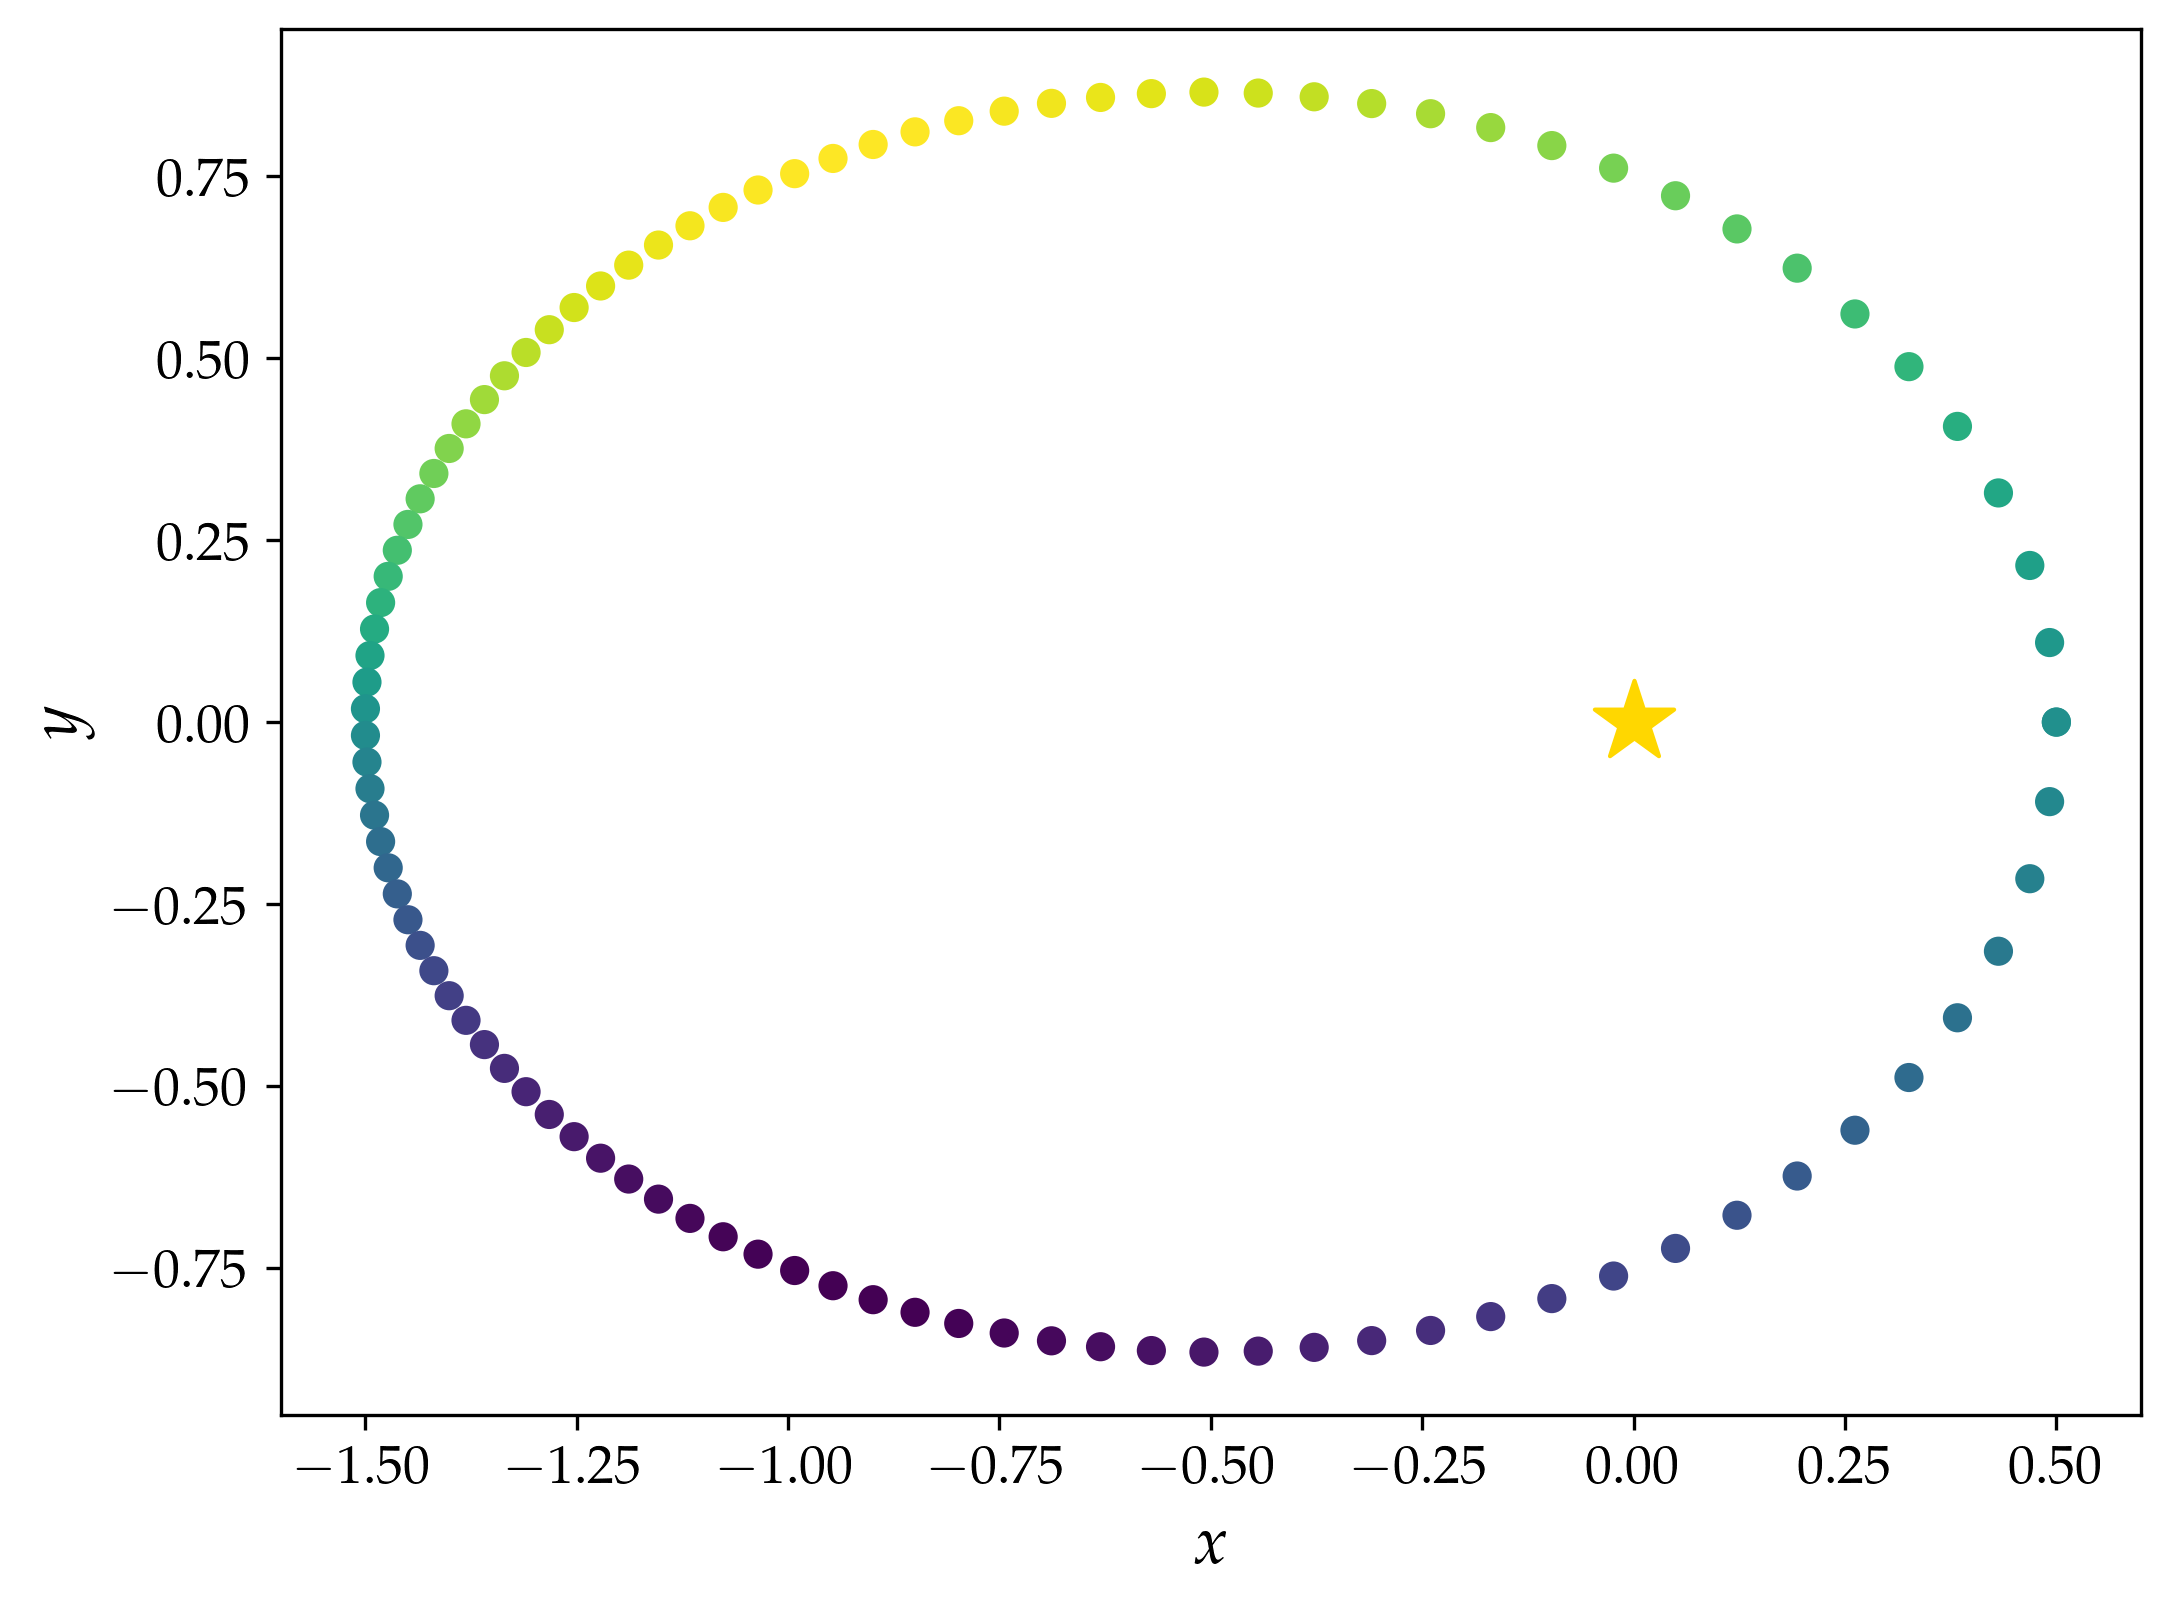

In [203]:
e = 0.5
a = 1
M_t = lambda t: 0.5 * t

# M(T) = 0.5*T = 2*pi - e*sin(2*pi)    ----->    0.5T - 2pi = 0
find_T = lambda t: M_t(t) - 2 * np.pi

# Research of the period for a given E_t, eccentric anomaly
T = bisec(find_T, 0, 20)
print(f'T = {T}')

# Evaluate E_t

t_span = np.linspace(0, T, 100)
M_ts = np.array([M_t(t) for t in t_span])

E_ls = []

for i, M_ti in enumerate(M_ts):
    find_Et = lambda E_t: E_t - e * np.sin(E_t) - M_ti
    zero = bisec(find_Et, 0, 20)
    E_ls.append(zero)
E_ts = np.array(E_ls)

find_xt = lambda E_ti: a * (np.cos(E_ti) - e)
find_yt = lambda E_ti: a * np.sqrt(1 - e**2) * np.sin(E_ti)
x_ts = np.array([find_xt(E_ti) for E_ti in E_ts])
y_ts = np.array([find_yt(E_ti) for E_ti in E_ts])

plt.figure()
colors = np.sin(t_span/2.0)

plt.scatter(x_ts, y_ts, c = colors, cmap='viridis')
plt.scatter(0, 0, marker='*', s=400, color="gold")
plt.xlabel('$x$')
plt.ylabel('$y$');

plt.savefig('plots/color_orbit.png')
plt.show()


## **Kepler's root finders comparison**


BISECTION MTH
     Found f(c) = 0:  c =  0.3354180343449116
     N_iter =  29

REGULA FALSI
     Found f(c) = 0:  c =  0.33541803238804735
     N_iter =  5

diff = 1.956864226215771e-09


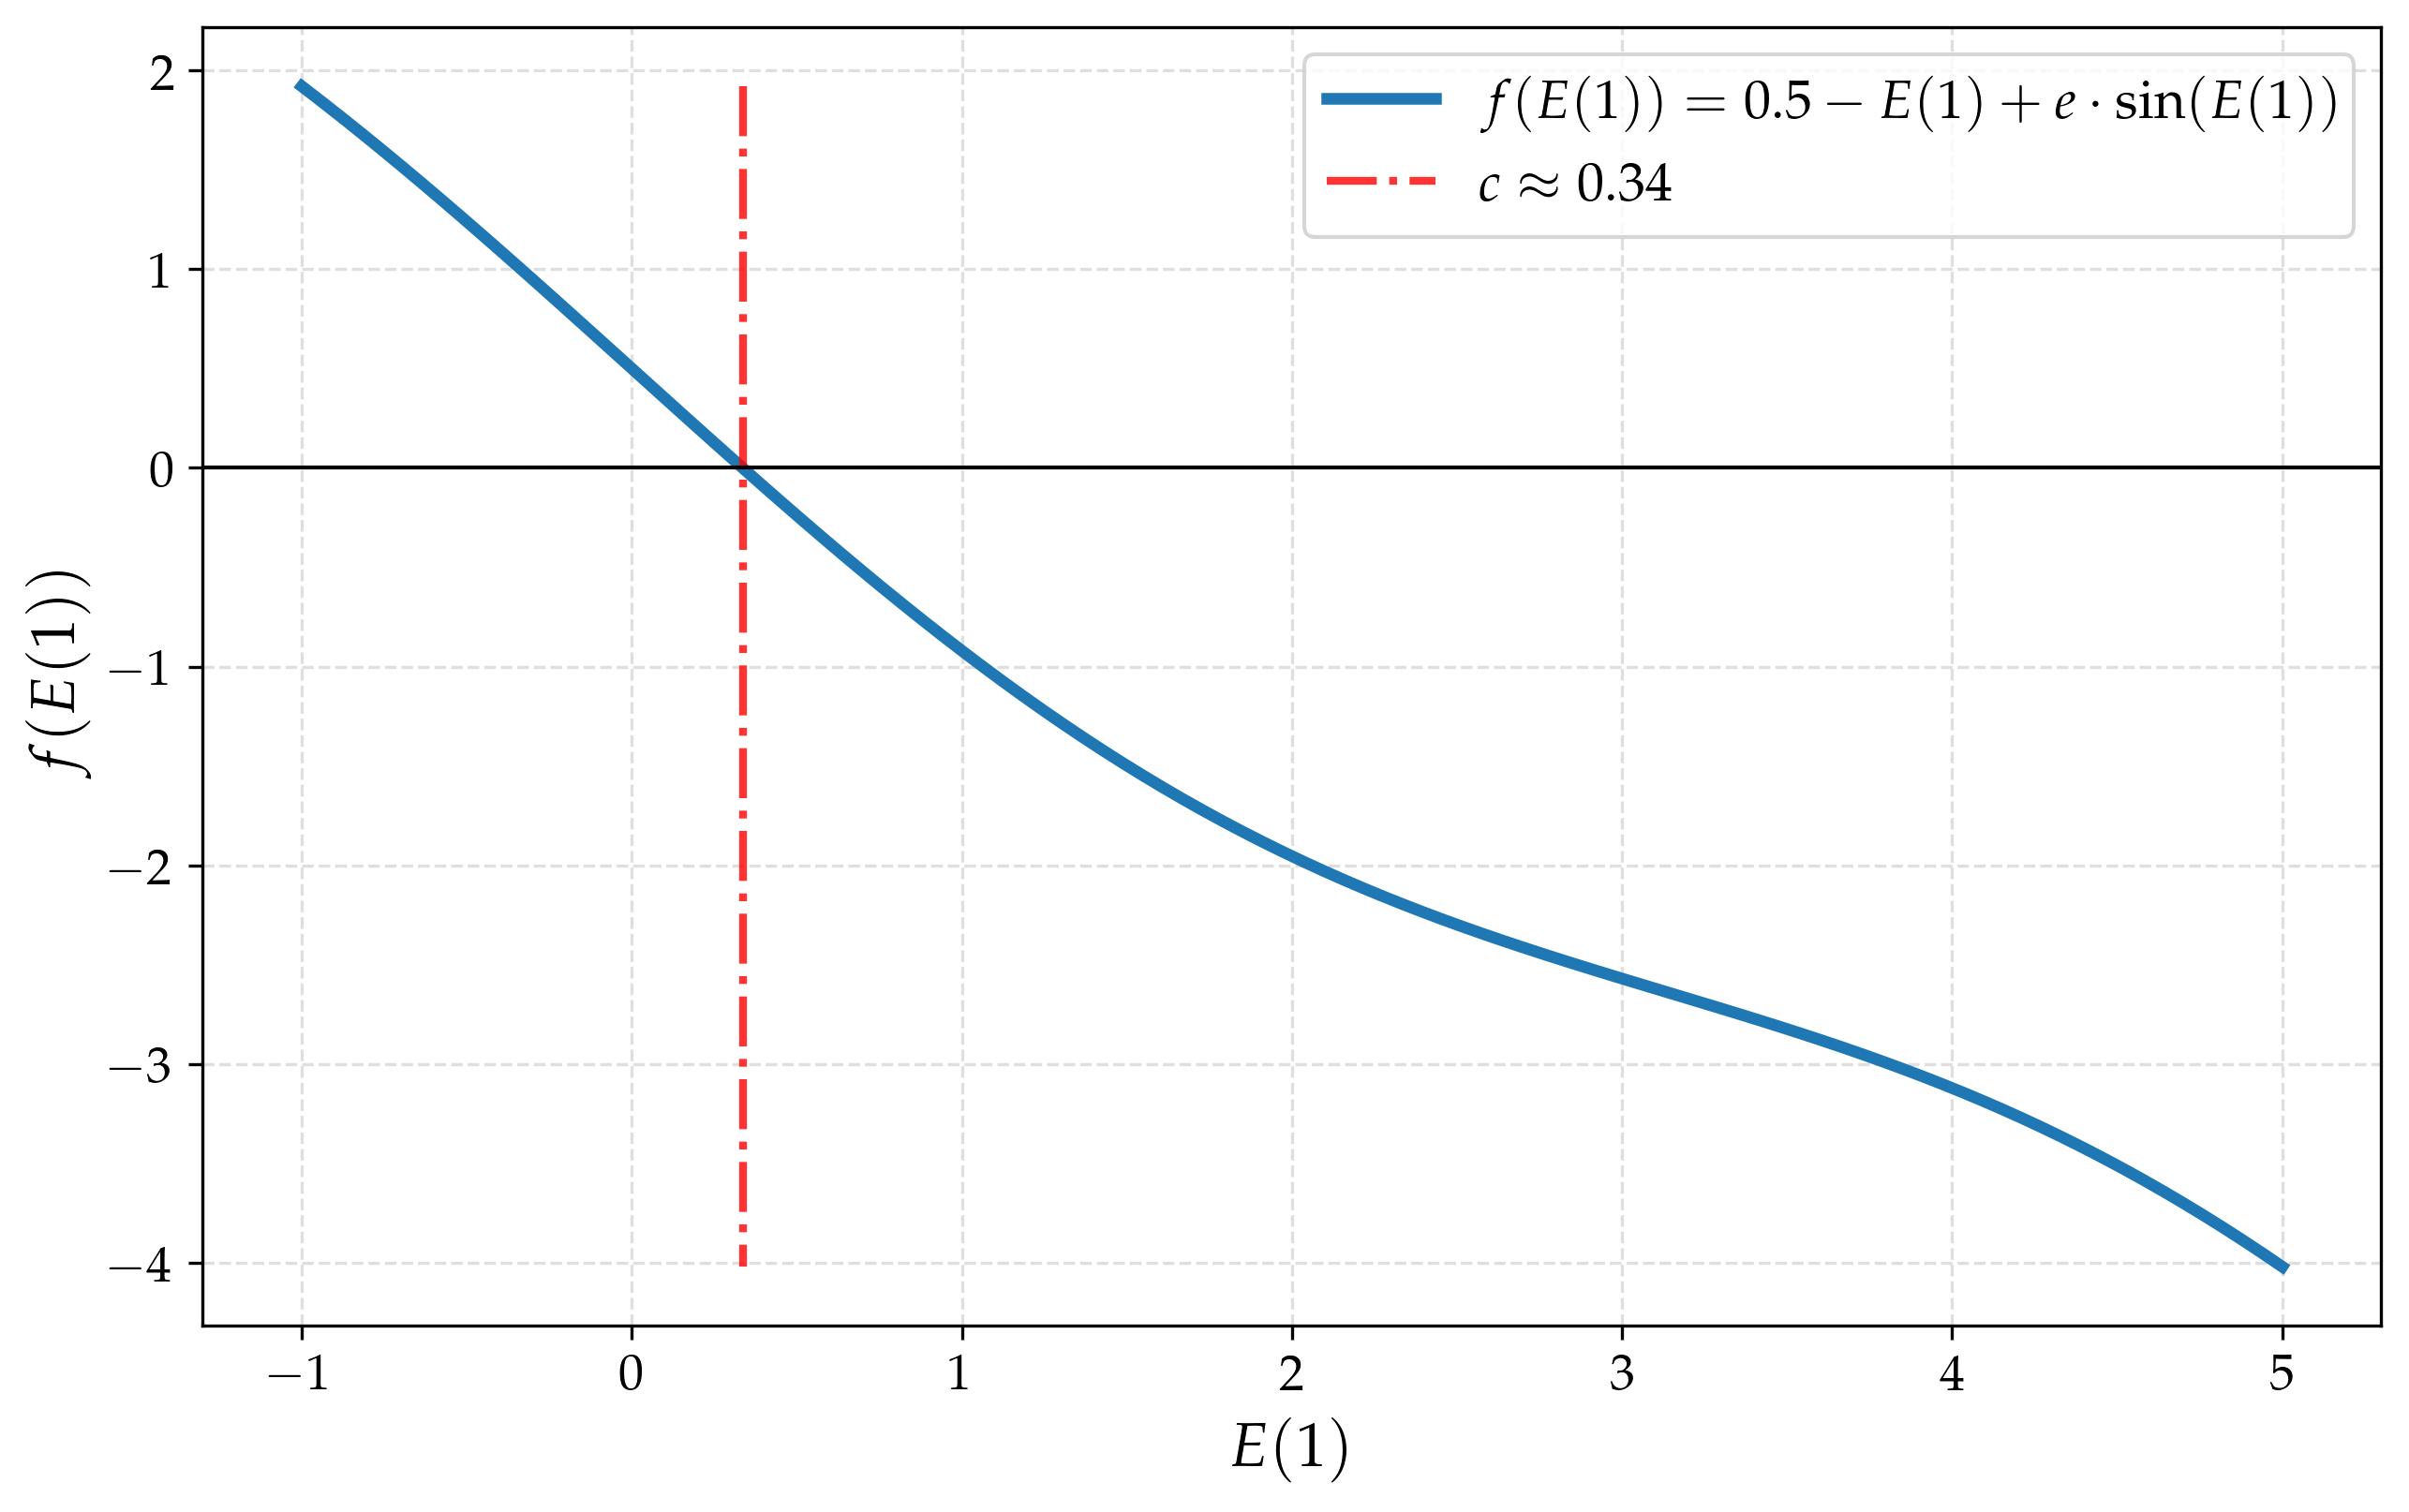

In [204]:
func = lambda E_1: 0.5 - E_1 - e * np.sin(E_1)

start, end = (-1, 5)
xcoo = np.linspace(start, end, 100)
ycoo = func(xcoo)

c_clas, N_iter = bisec(func, start, end, optim=False, out_niter=True)
print('\nBISECTION MTH')
print('     Found f(c) = 0:  c = ', c_clas)
print('     N_iter = ', N_iter)

print()
c_optim, N_iter = bisec(func, start, end, optim=True, out_niter=True)
print('REGULA FALSI')
print('     Found f(c) = 0:  c = ', c_optim)
print('     N_iter = ', N_iter)


diff = abs(c_clas - c_optim)
print('\ndiff =', diff)

plt.figure(figsize=(10, 6))
plt.plot(xcoo, ycoo, label=r'$f(E(1)) = 0.5 - E(1) + e \cdot \text{sin}(E(1))$', lw=3)
plt.vlines(c_optim, max(ycoo), min(ycoo), ls='-.', lw=2, color='red', alpha=0.8, label=rf'$c \approx {c_optim:.2f}$')

plt.xlabel(r'$E(1)$')
plt.ylabel(r'$f(E(1))$')
plt.axhline(0, color='black', linewidth=1)
plt.grid(alpha=0.4, ls='--')
plt.legend(loc='upper right')

plt.savefig('plots/plot_Kep_zero.png')
plt.show()


BISECTION MTH


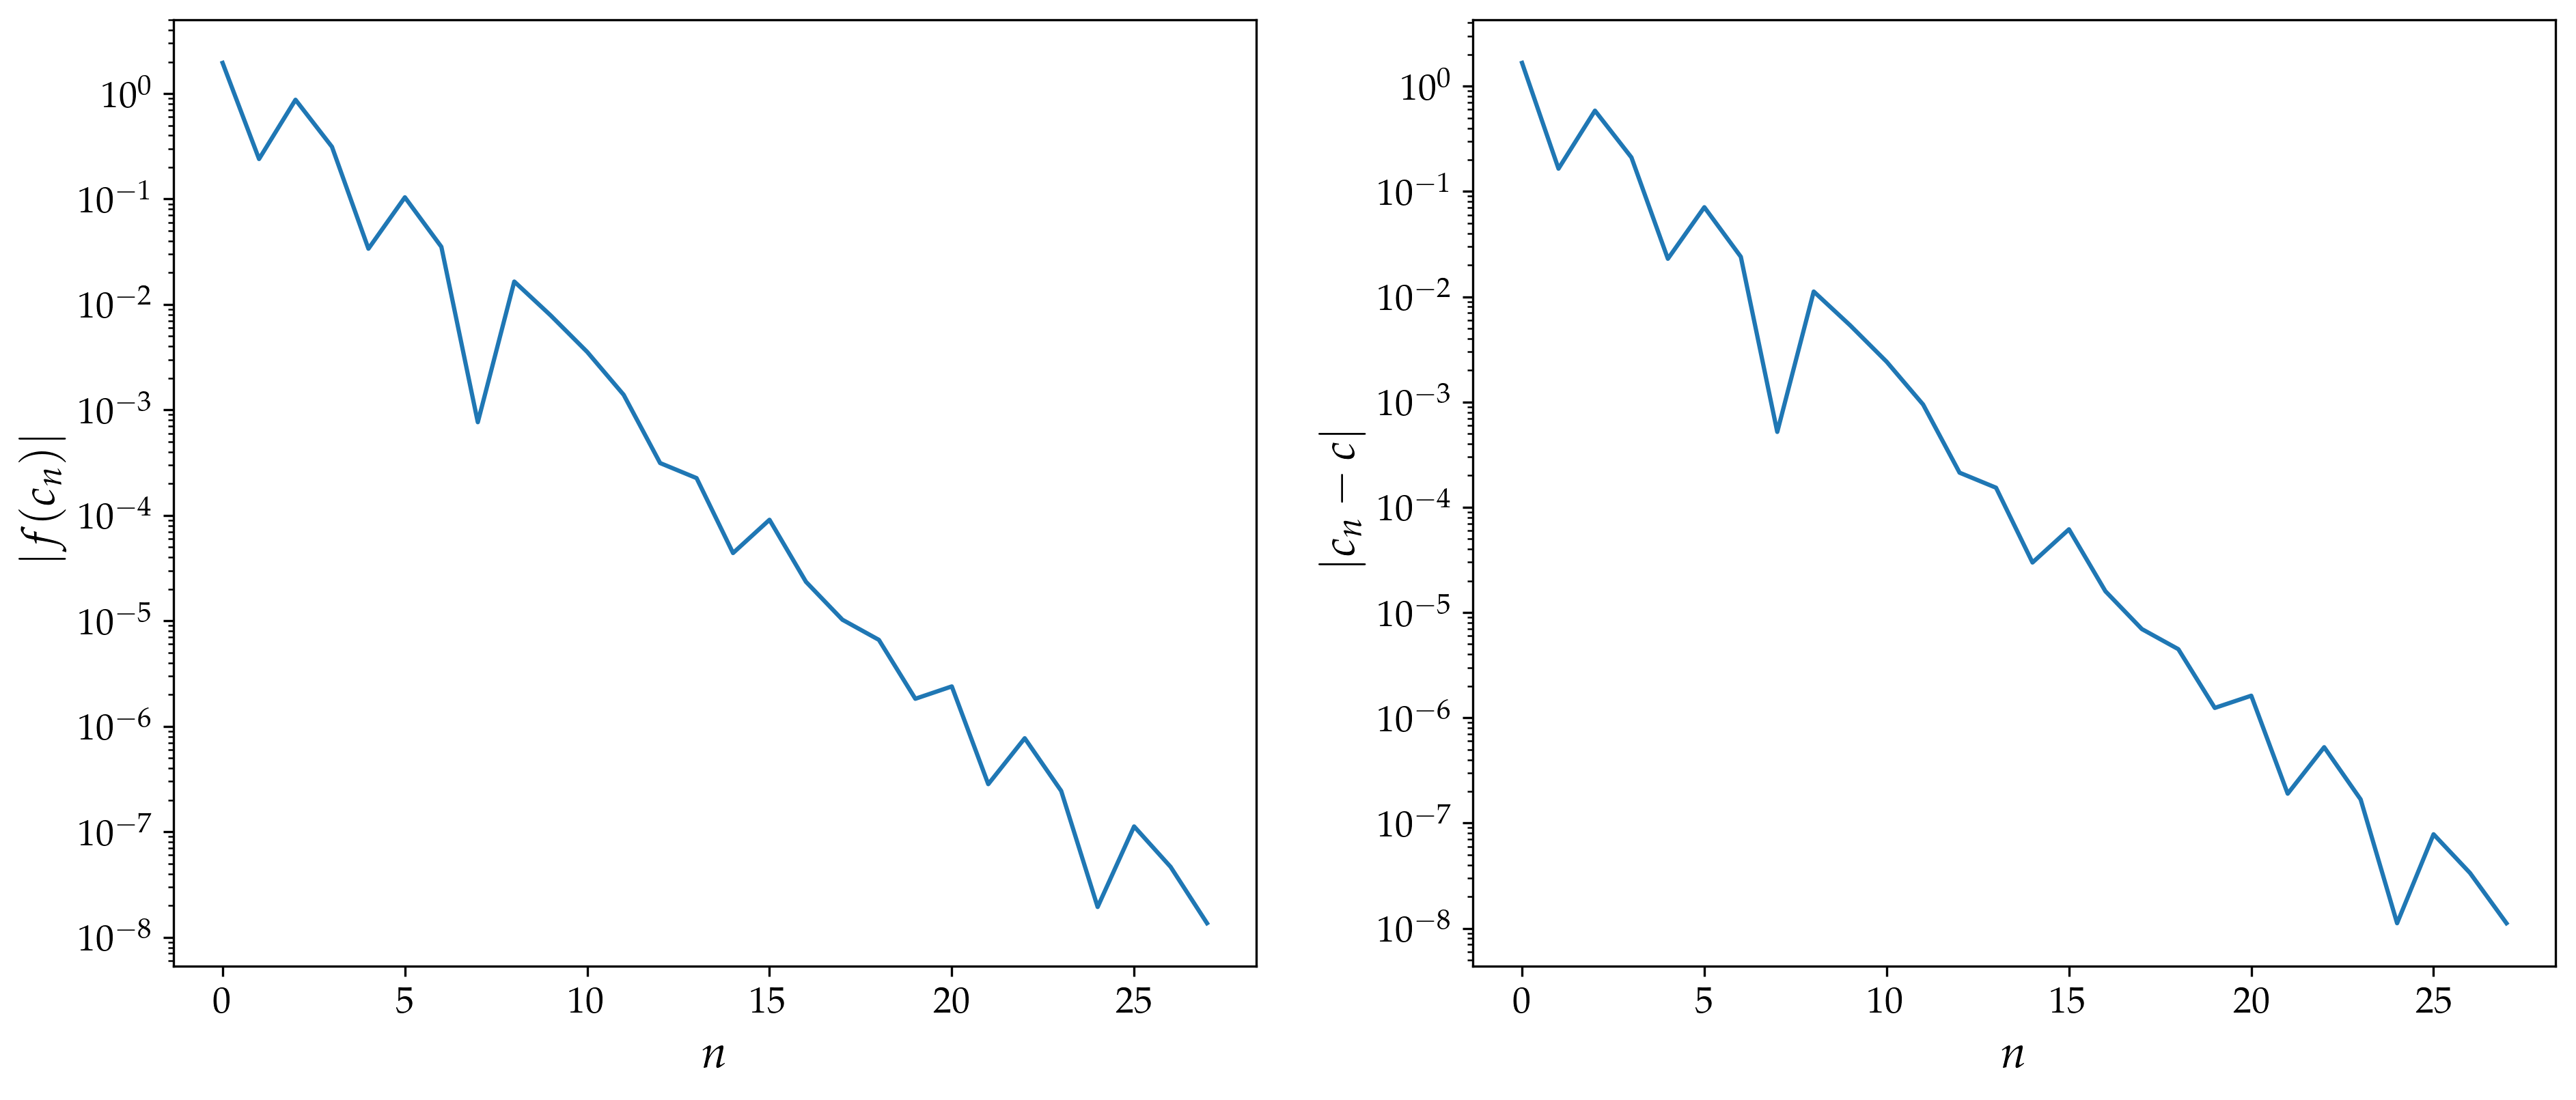

REGULA FALSI


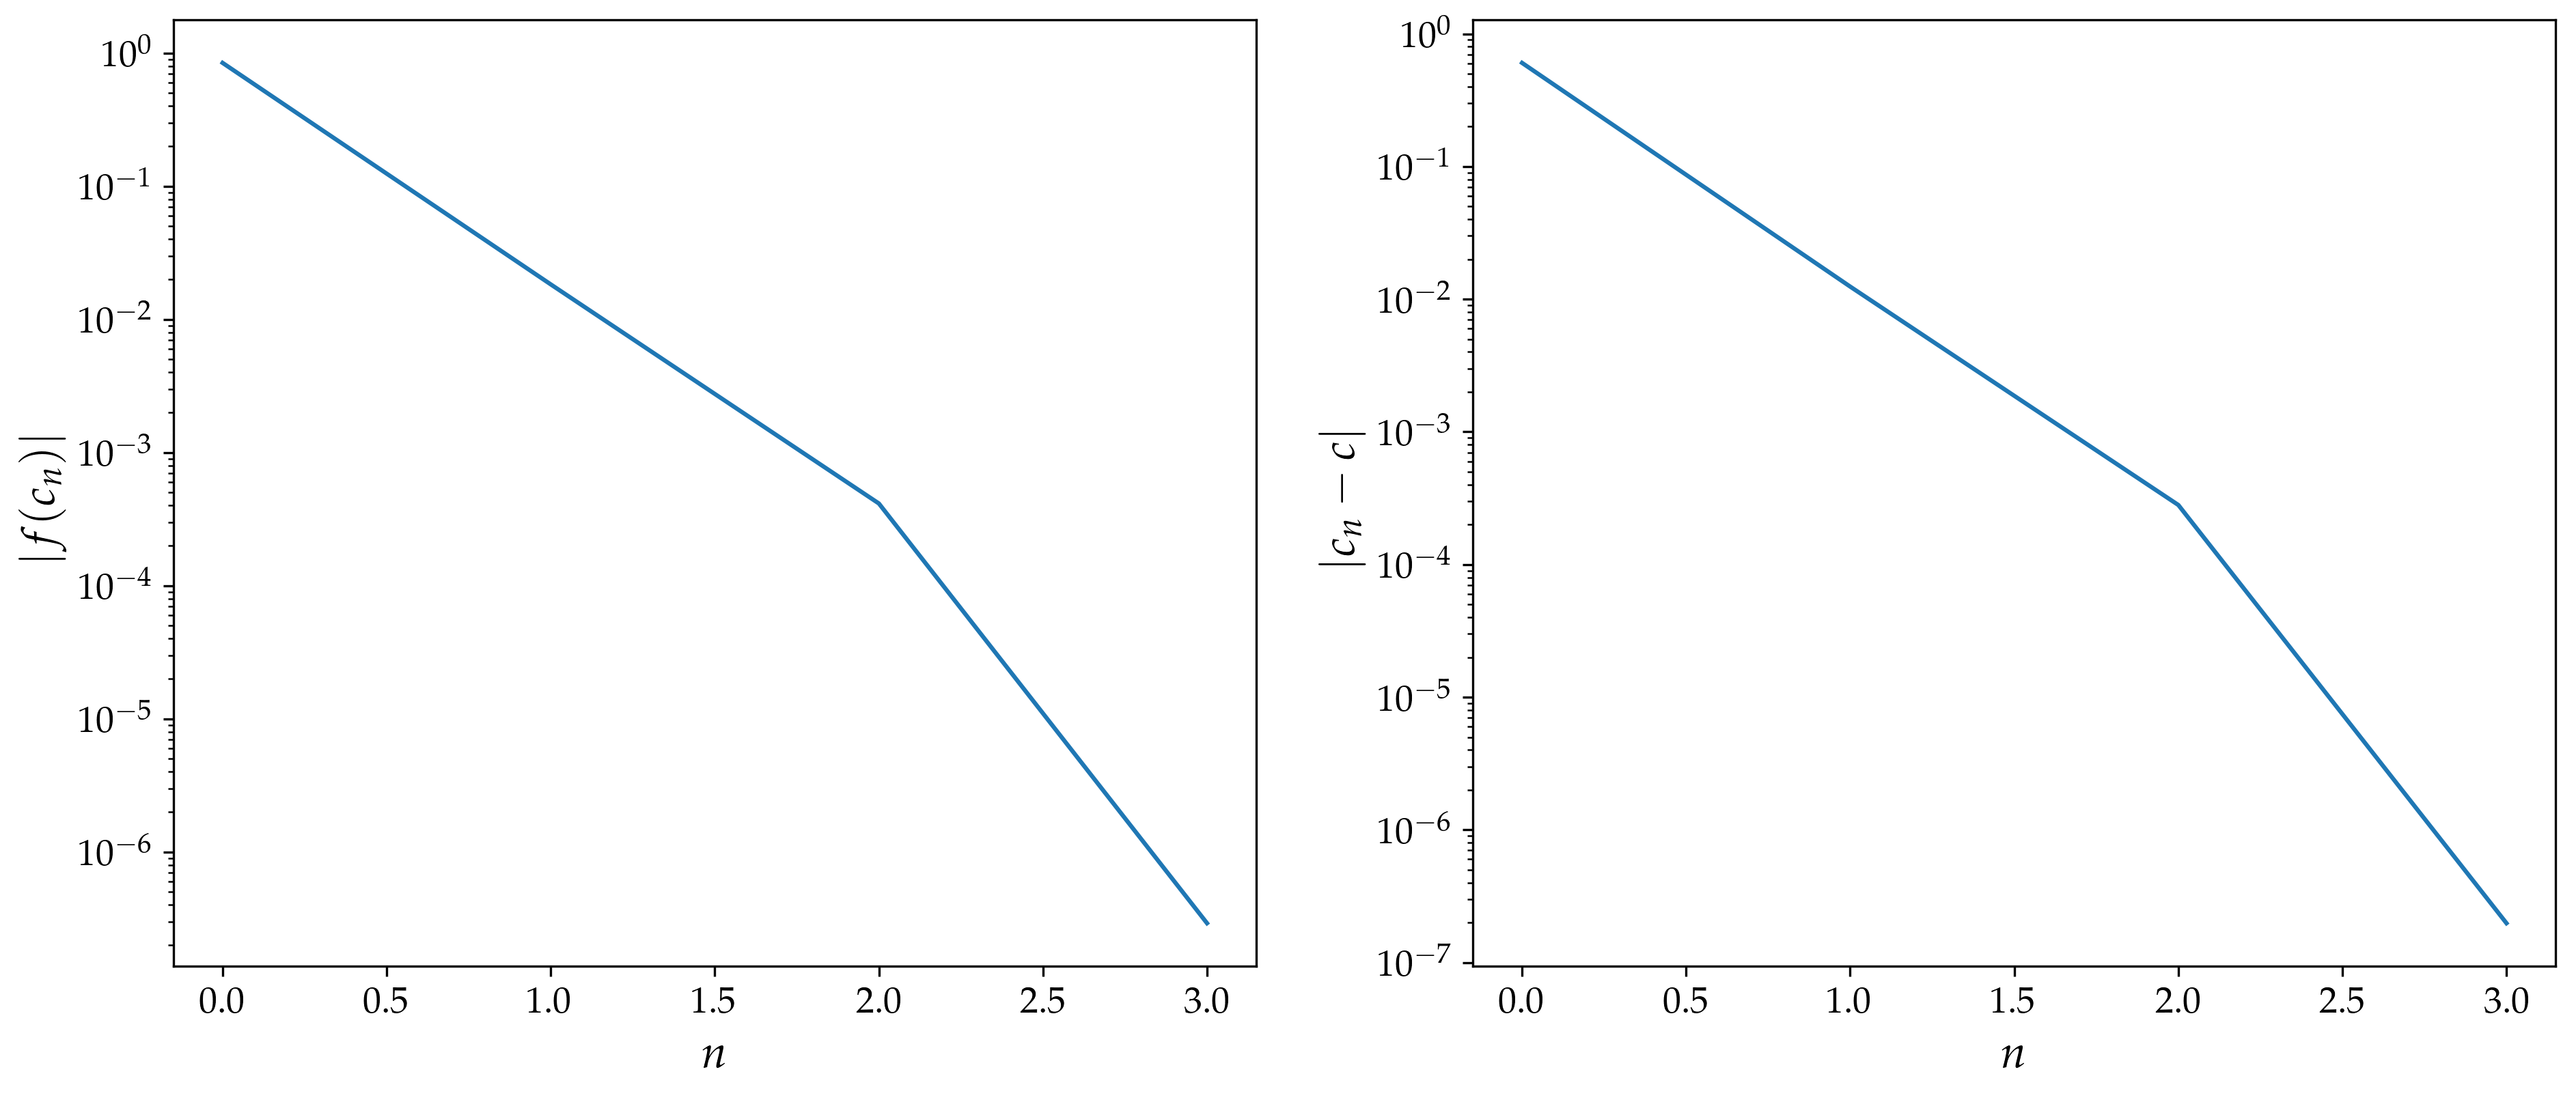

In [205]:
def plot_bisec(f, a, b, optim=True, tol=1e-8, MaxIter=500):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError('f(a) and f(b) must have different sign!')

    n_iter = 0
    f_ls = []
    diff_c = []

    while n_iter < MaxIter:
        if optim:
            den = fb - fa
            if abs(den) < tol: 
                c = (a + b) / 2
            else:
                c = (a * fb - b * fa) / den
        else:
            c = (a + b) / 2

        fc = f(c)

        if fa * fc > 0:
            a, fa = c, fc
        else:
            b, fb = c, fc
        
        diff_c.append(c)
        f_ls.append(fc)
        n_iter += 1
        
        if abs(fc) < tol or abs(b - a) < tol:
            break
            
    return f_ls, diff_c, c, n_iter

def plotty(res, name):
    fls, cls, c, niter = res
    xcoo = np.arange(0, niter)[:-1]
    f = abs(np.array(fls))[:-1]
    cs = abs(np.array(cls) - cls[-1])[:-1]

    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    ax[0].plot(xcoo, f)
    ax[0].set_xlabel(r'$n$')
    ax[0].set_ylabel(r'$|f(c_n)|$')
    ax[0].set_yscale('log')

    ax[1].plot(xcoo, cs)
    ax[1].set_xlabel(r'$n$')
    ax[1].set_ylabel(r'$|c_n - c|$')
    ax[1].set_yscale('log')
    plt.savefig('plots/'+name+'.png')
    plt.show()

print('\nBISECTION MTH')
plotty(plot_bisec(func, start, end, optim=False), 'bis_kep')

print('REGULA FALSI')
plotty(plot_bisec(func, start, end, optim=True,), 'optim_kep')
